<a href="https://colab.research.google.com/github/malanda20/Data-Science/blob/main/Metrics_001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MAE : 41.91937845679274
MSE : 2821.750981001311
RMSE: 53.120156070942706
R²  : 0.4772897164322617
Adj R²: 0.43444461122179134


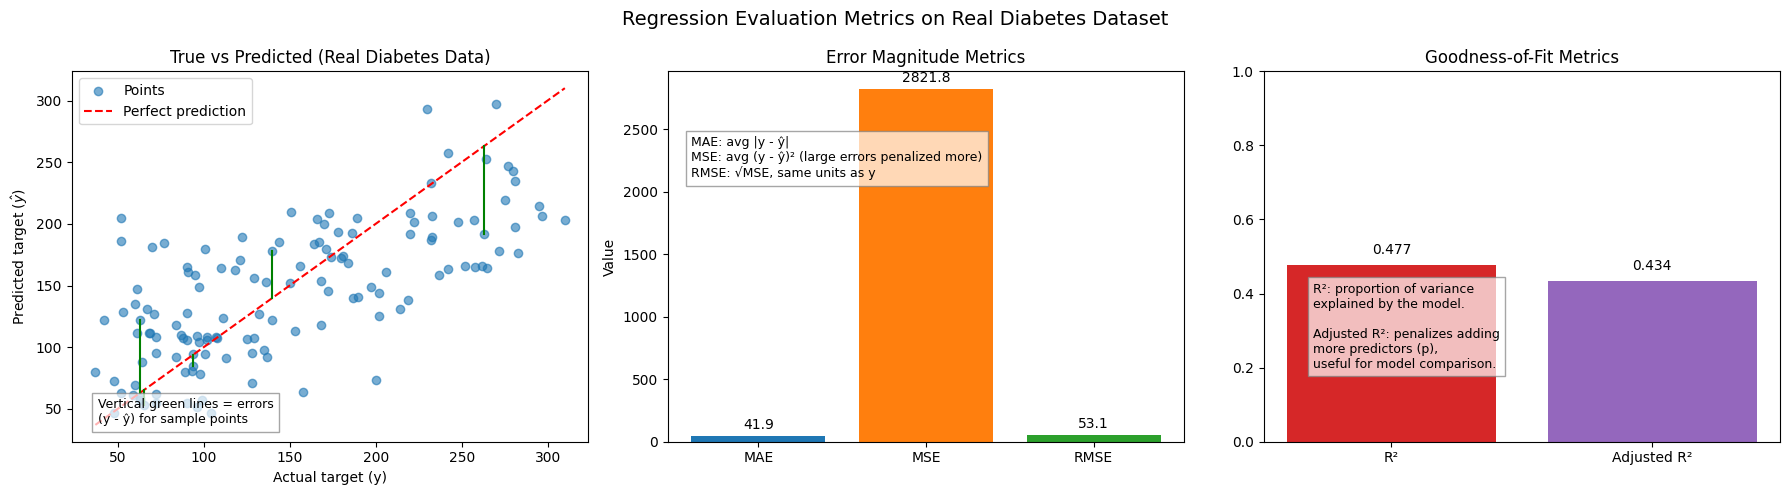

In [ ]:
# ============================================================
# Regression Metrics Demo on Real Diabetes Dataset
# Metrics: MAE, MSE, RMSE, R², Adjusted R²
# ============================================================


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load a real regression dataset (Diabetes)
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target


# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# 3. Fit a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# 4. Compute metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


n, p = X_test.shape  # n samples, p features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adj R²:", adj_r2)


# 5. Pick a few sample points to illustrate individual errors (residuals)
np.random.seed(0)
idx_samples = np.random.choice(len(y_test), size=5, replace=False)
y_true_samples = y_test[idx_samples]
y_pred_samples = y_pred[idx_samples]


# 6. Create a multi-panel figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# ------------------------------------------------------------
# Panel 1: True vs Predicted with residuals
# ------------------------------------------------------------
axes[0].scatter(y_test, y_pred, alpha=0.6, label="Points")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label="Perfect prediction"
)
axes[0].set_title("True vs Predicted (Real Diabetes Data)")
axes[0].set_xlabel("Actual target (y)")
axes[0].set_ylabel("Predicted target ($\\hat{y}$)")
axes[0].legend()


# Highlight residuals (errors) for selected points
for yt, yp in zip(y_true_samples, y_pred_samples):
    # vertical line from (yt, yt) to (yt, yp)
    axes[0].plot([yt, yt], [yt, yp], 'g-')


axes[0].text(
    0.05,
    0.05,
    "Vertical green lines = errors\n(y - ŷ) for sample points",
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)


# ------------------------------------------------------------
# Panel 2: MAE, MSE, RMSE bar chart
# ------------------------------------------------------------
metrics_names = ["MAE", "MSE", "RMSE"]
metrics_vals = [mae, mse, rmse]


axes[1].bar(metrics_names, metrics_vals, color=["C0", "C1", "C2"])
axes[1].set_title("Error Magnitude Metrics")
axes[1].set_ylabel("Value")


# Label each bar with its value
for i, v in enumerate(metrics_vals):
    axes[1].text(i, v + max(metrics_vals) * 0.02, f"{v:.1f}", ha="center")


axes[1].text(
    -0.4,
    max(metrics_vals) * 0.75,
    "MAE: avg |y - ŷ|\n"
    "MSE: avg (y - ŷ)² (large errors penalized more)\n"
    "RMSE: √MSE, same units as y",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)


# ------------------------------------------------------------
# Panel 3: R² vs Adjusted R²
# ------------------------------------------------------------
axes[2].bar(["R²", "Adjusted R²"], [r2, adj_r2], color=["C3", "C4"])
axes[2].set_ylim(0, 1)
axes[2].set_title("Goodness-of-Fit Metrics")


for i, v in enumerate([r2, adj_r2]):
    axes[2].text(i, v + 0.03, f"{v:.3f}", ha="center")


axes[2].text(
    -0.3,
    0.2,
    "R²: proportion of variance\nexplained by the model.\n\n"
    "Adjusted R²: penalizes adding\nmore predictors (p),\nuseful for model comparison.",
    fontsize=9,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
)


# ------------------------------------------------------------
fig.suptitle("Regression Evaluation Metrics on Real Diabetes Dataset", fontsize=14)
plt.tight_layout()
plt.show()